In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("penguins")
df.to_csv("penguins.csv", index=False)   # este é o arquivo que vai para dados/ no GitHub

print("Linhas e colunas:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())
print("\nEstatísticas básicas:")
print(df.describe())
print("\nLinhas por espécie:")
print(df["species"].value_counts())
print("\nEstatísticas da massa corporal por espécie:")
print(df.groupby("species")["body_mass_g"].describe())

Linhas e colunas: (344, 7)

Tipos de dados:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Valores ausentes por coluna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Estatísticas básicas:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000 

## **Probabilidade acima da mediana**

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# Carrega a base e filtra só a espécie Adélie
df = sns.load_dataset("penguins")
adelie = df[df["species"] == "Adelie"].copy()
adelie = adelie.dropna(subset=["body_mass_g"])  # remove ausentes na variável usada

var = adelie["body_mass_g"]

# Estatísticas da amostra
mediana = var.median()
media = var.mean()
desvio = var.std()

# Assumindo Normal(media, desvio), calcula P(X > mediana)
prob_acima_mediana = 1 - stats.norm.cdf(mediana, loc=media, scale=desvio)

print(f"Quantidade de pinguins Adélie analisados: {len(var)}")
print(f"Mediana da massa corporal: {mediana:.2f} g")
print(f"Média: {media:.2f} g")
print(f"Desvio-padrão: {desvio:.2f} g")
print(f"P(X > mediana) = {prob_acima_mediana*100:.2f}%")

# Classificação do evento
def classificar(p):
    if p < 0.10:
        return "raro"
    elif p < 0.50:
        return "pouco provável"
    elif p < 0.90:
        return "provável"
    else:
        return "quase certo"

print("Classificação:", classificar(prob_acima_mediana))

Quantidade de pinguins Adélie analisados: 151
Mediana da massa corporal: 3700.00 g
Média: 3700.66 g
Desvio-padrão: 458.57 g
P(X > mediana) = 50.06%
Classificação: provável


média e mediana ficaram praticamente iguais (3700,66 vs 3700,00), o que é o comportamento esperado numa distribuição Normal. Por isso a probabilidade deu bem perto de 50%, e não exatamente 50%, porque calculamos a mediana a partir dos dados reais, e ela quase nunca coincide de forma perfeita com a média. Isso confirma que restringir a análise à espécie Adélie foi a escolha certa: os dados ficaram bem comportados, parecidos com um sino.

## **Probabilidade no intervalo (média ± 2 desvios-padrão)**

In [ ]:
# Reaproveita a variável 'adelie' e 'var' já criadas na célula da Questão 1
# Se estiver em uma célula nova e isolada, descomente as linhas abaixo:
# adelie = df[df["species"] == "Adelie"].copy()
# adelie = adelie.dropna(subset=["body_mass_g"])
# var = adelie["body_mass_g"]

media = var.mean()
desvio = var.std()

limite_inferior = media - 2 * desvio
limite_superior = media + 2 * desvio

# P(limite_inferior <= X <= limite_superior), assumindo Normal(media, desvio)
prob_intervalo = stats.norm.cdf(limite_superior, loc=media, scale=desvio) - \
                  stats.norm.cdf(limite_inferior, loc=media, scale=desvio)

print(f"Média: {media:.2f} g")
print(f"Desvio-padrão: {desvio:.2f} g")
print(f"Limite inferior (média - 2s): {limite_inferior:.2f} g")
print(f"Limite superior (média + 2s): {limite_superior:.2f} g")
print(f"P(limite_inferior <= X <= limite_superior) = {prob_intervalo*100:.2f}%")
print("Classificação:", classificar(prob_intervalo))

# Comparação com a proporção real de dados dentro do intervalo (checagem extra)
dentro_intervalo = var[(var >= limite_inferior) & (var <= limite_superior)]
proporcao_real = len(dentro_intervalo) / len(var)
print(f"\nProporção real de dados dentro do intervalo: {proporcao_real*100:.2f}%")

Média: 3700.66 g
Desvio-padrão: 458.57 g
Limite inferior (média - 2s): 2783.53 g
Limite superior (média + 2s): 4617.79 g
P(limite_inferior <= X <= limite_superior) = 95.45%
Classificação: quase certo

Proporção real de dados dentro do intervalo: 96.69%


o resultado teórico (95,45%) bate exatamente com a regra empírica 68-95-99,7 de uma distribuição Normal, que diz que aproximadamente 95% dos dados ficam dentro de média ± 2 desvios-padrão. Além disso, quando conferimos direto nos dados reais (sem assumir Normalidade), 96,69% dos pinguins realmente caem dentro desse intervalo — um valor bem próximo do teórico, o que reforça que a suposição de Normal foi adequada para essa variável.

# Regressão Linear

Quantidade de dados usados: 151
Intercepto (b0): -2535.84
Coeficiente angular (b1): 32.83
Equação: body_mass_g = -2535.84 + 32.83 * flipper_length_mm
R²: 0.2192


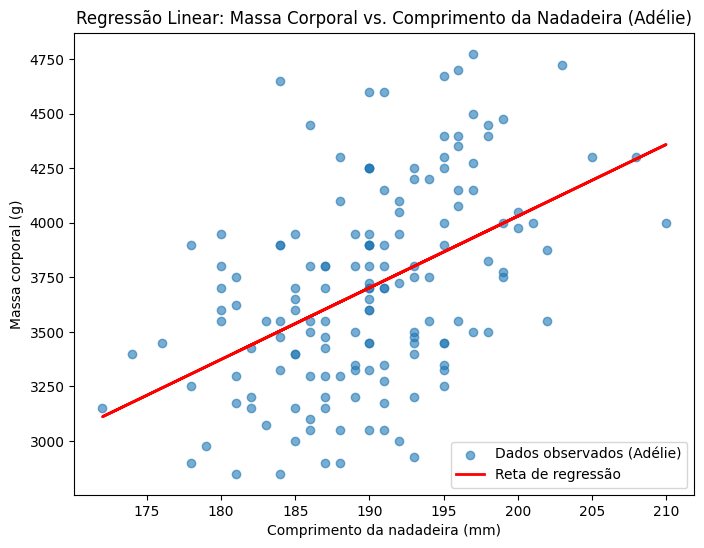

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Reaproveita 'adelie' já filtrada (só Adélie, sem NaN em body_mass_g)
# Garantir que não há ausentes nas duas variáveis usadas na regressão
dados_reg = adelie.dropna(subset=["flipper_length_mm", "body_mass_g"])

X = dados_reg[["flipper_length_mm"]]  # variável independente
y = dados_reg["body_mass_g"]          # variável dependente

# Treina o modelo
modelo = LinearRegression()
modelo.fit(X, y)

intercepto = modelo.intercept_
coef_angular = modelo.coef_[0]
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

print(f"Quantidade de dados usados: {len(dados_reg)}")
print(f"Intercepto (b0): {intercepto:.2f}")
print(f"Coeficiente angular (b1): {coef_angular:.2f}")
print(f"Equação: body_mass_g = {intercepto:.2f} + {coef_angular:.2f} * flipper_length_mm")
print(f"R²: {r2:.4f}")

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6, label="Dados observados (Adélie)")
plt.plot(X, y_pred, color="red", linewidth=2, label="Reta de regressão")
plt.title("Regressão Linear: Massa Corporal vs. Comprimento da Nadadeira (Adélie)")
plt.xlabel("Comprimento da nadadeira (mm)")
plt.ylabel("Massa corporal (g)")
plt.legend()
plt.savefig("regressao_linear.png", dpi=150, bbox_inches="tight")  # salva para colocar em graficos/
plt.show()

Os resultados mostram que existe uma relação positiva entre o comprimento da nadadeira e a massa corporal dos pinguins Adélie: para cada 1 mm a mais de nadadeira, o modelo estima um aumento médio de 32,83 g na massa. Isso faz sentido biologicamente, já que pinguins estruturalmente maiores tendem a pesar mais. No entanto, o R² obtido foi de 0,2192, o que significa que o comprimento da nadadeira explica apenas cerca de 22% da variação da massa corporal, indicando uma relação positiva, porém fraca. Isso sugere que outros fatores não incluídos no modelo, como sexo, comprimento e profundidade do bico, também influenciam o peso dos pinguins. Vale destacar ainda que a análise foi feita apenas com a espécie Adélie, e que a existência de uma relação linear não implica que uma variável cause a outra.